##### ARTI 560 - Computer Vision

## Visual Representations with DINOv2 - Exercise

### Exercise 1: Unsupervised Clustering

In this exercise, you will use the `KMeans` algorithm from sklearn to group 20 images from the Oxford Pet dataset into 2 clusters (Cats vs. Dogs) based purely on their CLS tokens.

Instructions:

1.  Extract the 384-dimensional [CLS] tokens from 20 images of the Oxford-IIIT Pet dataset. Ensure your selection includes a mix of both cats and dogs.

2. Apply K-Means Clustering ($n=2$) to group the vectors based on mathematical similarity rather than provided labels.

3. Compare the predicted clusters against ground-truth labels.

Ground-truth label distribution: Counter({'cat': 10, 'dog': 10})


Loading weights:   0%|          | 0/223 [00:00<?, ?it/s]

Using device: cpu
CLS token matrix shape: (20, 384)


,image,ground_truth,cluster_id,predicted_label,correct
0,Abyssinian_113.jpg,cat,0,cat,True
1,Abyssinian_117.jpg,cat,0,cat,True
2,american_bulldog_116.jpg,dog,1,dog,True
3,american_bulldog_186.jpg,dog,1,dog,True
4,american_pit_bull_terrier_145.jpg,dog,1,dog,True
5,american_pit_bull_terrier_151.jpg,dog,1,dog,True
6,basset_hound_110.jpg,dog,1,dog,True
7,basset_hound_133.jpg,dog,1,dog,True
8,beagle_117.jpg,dog,1,dog,True
9,beagle_175.jpg,dog,1,dog,True


Cluster-to-label mapping: {0: 'cat', 1: 'dog'}
Clustering accuracy after majority-vote mapping: 100.00%
Adjusted Rand Index: 1.000
Confusion matrix rows=true [cat, dog], columns=predicted [cat, dog]:
[[10  0]
 [ 0 10]]


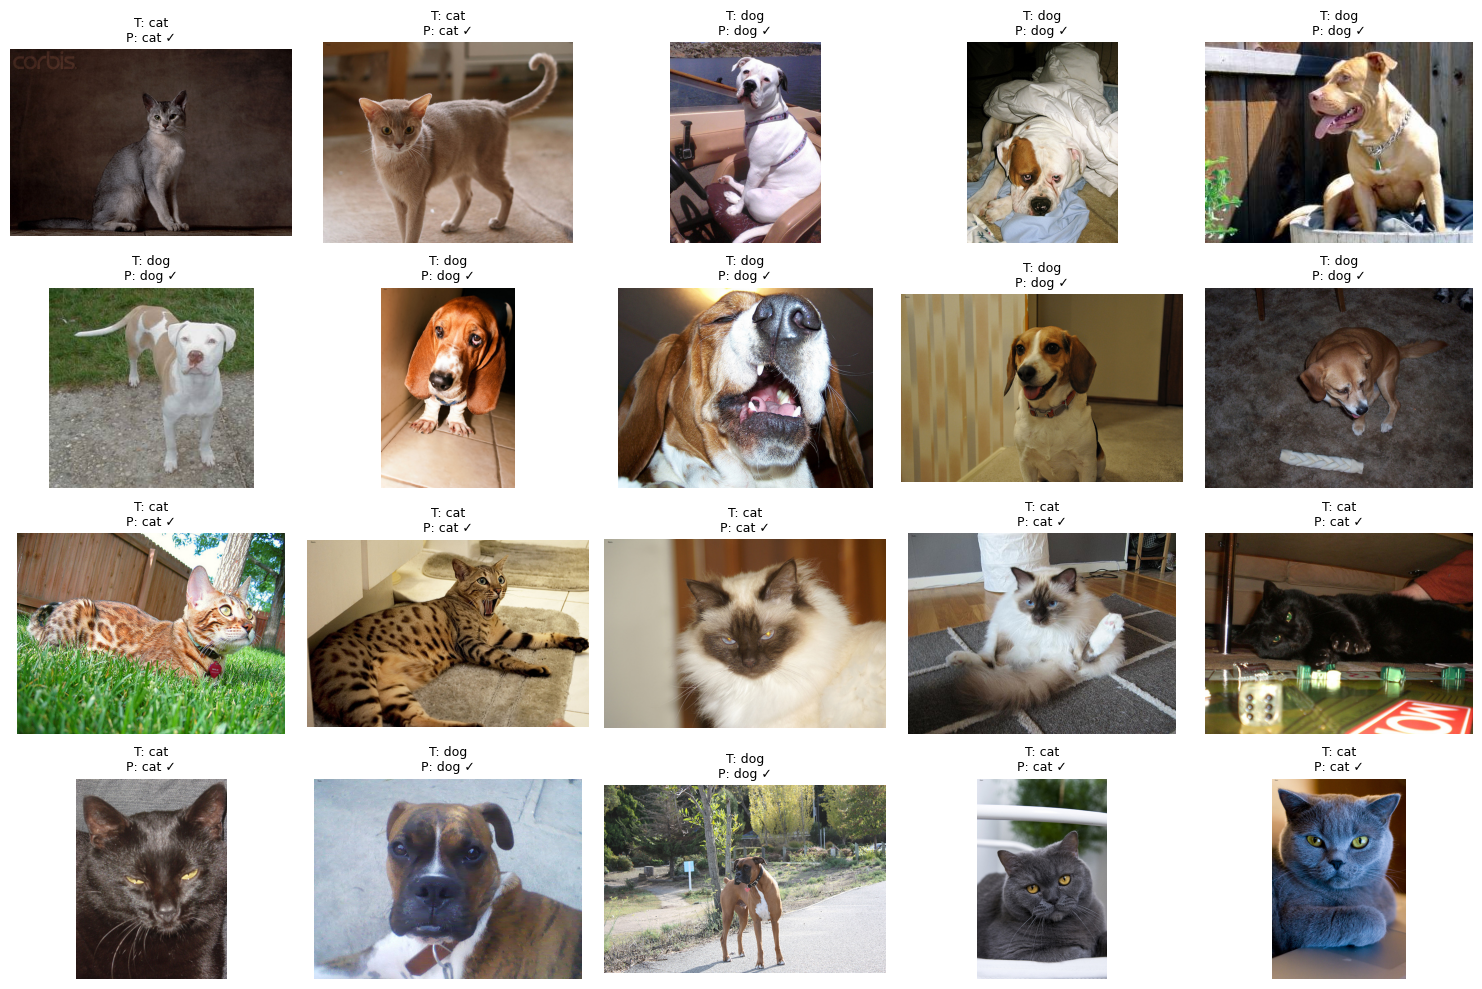

In [ ]:
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt

from PIL import Image
from transformers import AutoImageProcessor, AutoModel
from sklearn.cluster import KMeans
from sklearn.metrics import accuracy_score, adjusted_rand_score, confusion_matrix

image_paths = [
    "data/Abyssinian_113.jpg",
    "data/Abyssinian_117.jpg",
    "data/american_bulldog_116.jpg",
    "data/american_bulldog_186.jpg",
    "data/american_pit_bull_terrier_145.jpg",
    "data/american_pit_bull_terrier_151.jpg",
    "data/basset_hound_110.jpg",
    "data/basset_hound_133.jpg",
    "data/beagle_117.jpg",
    "data/beagle_175.jpg",
    "data/Bengal_10.jpg",
    "data/Bengal_125.jpg",
    "data/Birman_107.jpg",
    "data/Birman_167.jpg",
    "data/Bombay_40.jpg",
    "data/Bombay_72.jpg",
    "data/boxer_10.jpg",
    "data/boxer_129.jpg",
    "data/British_Shorthair_127.jpg",
    "data/British_Shorthair_168.jpg"
]

def get_pet_label(path):
    filename = Path(path).name
    return "cat" if filename[0].isupper() else "dog"

ground_truth = [get_pet_label(p) for p in image_paths]
label_to_id = {"cat": 0, "dog": 1}
y_true = np.array([label_to_id[label] for label in ground_truth])

print("Ground-truth label distribution:", Counter(ground_truth))

model_id = "facebook/dinov2-small"
processor = AutoImageProcessor.from_pretrained(model_id)
model = AutoModel.from_pretrained(model_id)
model.eval()

device = "cuda" if torch.cuda.is_available() else "cpu"
model.to(device)
print("Using device:", device)

images = []
missing = []
for path in image_paths:
    if not Path(path).exists():
        missing.append(path)
    else:
        images.append(Image.open(path).convert("RGB"))

if missing:
    raise FileNotFoundError(
        "These image paths were not found."
    )

cls_tokens = []
with torch.no_grad():
    for image in images:
        inputs = processor(images=image, return_tensors="pt").to(device)
        outputs = model(**inputs)
        cls_token = outputs.last_hidden_state[:, 0, :]  # [CLS] token, shape: (1, 384)
        cls_tokens.append(cls_token.cpu().numpy().squeeze())

X = np.vstack(cls_tokens)
print("CLS token matrix shape:", X.shape)  # expected: (20, 384)

kmeans = KMeans(n_clusters=2, random_state=42, n_init=10)
cluster_ids = kmeans.fit_predict(X)

cluster_to_label = {}
for cluster in sorted(set(cluster_ids)):
    indices = np.where(cluster_ids == cluster)[0]
    majority_label = Counter([ground_truth[i] for i in indices]).most_common(1)[0][0]
    cluster_to_label[cluster] = majority_label

pred_labels = [cluster_to_label[c] for c in cluster_ids]
y_pred = np.array([label_to_id[label] for label in pred_labels])

accuracy = accuracy_score(y_true, y_pred)
ari = adjusted_rand_score(y_true, cluster_ids)
cm = confusion_matrix(y_true, y_pred, labels=[0, 1])

results_df = pd.DataFrame({
    "image": [Path(p).name for p in image_paths],
    "ground_truth": ground_truth,
    "cluster_id": cluster_ids,
    "predicted_label": pred_labels,
    "correct": y_true == y_pred,
})

display(results_df)
print(f"Cluster-to-label mapping: {cluster_to_label}")
print(f"Clustering accuracy after majority-vote mapping: {accuracy:.2%}")
print(f"Adjusted Rand Index: {ari:.3f}")
print("Confusion matrix rows=true [cat, dog], columns=predicted [cat, dog]:")
print(cm)

fig, axes = plt.subplots(4, 5, figsize=(15, 10))
axes = axes.ravel()

for ax, image, row in zip(axes, images, results_df.itertuples(index=False)):
    ax.imshow(image)
    mark = "✓" if row.correct else "✗"
    ax.set_title(f"T: {row.ground_truth}\nP: {row.predicted_label} {mark}", fontsize=9)
    ax.axis("off")

plt.tight_layout()
plt.show()


### Exercise 2: Image Classification with DINOv2

In this exercise you'll use a DINOv2 model with a pre-trained linear head to classify an image. You will observe how the model maps visual features to specific ImageNet-1k categories.

Instructions:
1. For this exercise, you must use the following Model ID. This specific checkpoint includes the necessary classification head trained on ImageNet-1k:

    Model ID: `facebook/dinov2-small-imagenet1k-1-layer`

2. Find an image online to make the inference. To ensure the model has a fair chance of success, the image should belong to one of the ImageNet-1k classes (e.g., a Golden Retriever, a grand piano, a school bus, or a coffee mug).

Loading weights:   0%|          | 0/225 [00:00<?, ?it/s]

Using device: cpu


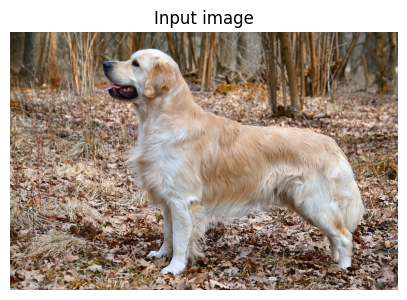

,rank,imagenet_class_id,label,probability
0,1,207,golden retriever,0.906669
1,2,208,Labrador retriever,0.025484
2,3,216,"clumber, clumber spaniel",0.023161
3,4,212,English setter,0.013459
4,5,220,Sussex spaniel,0.005115


Image source: data/Golden_Retriever_Carlos_(10581910556).jpg
Top prediction: golden retriever with probability 90.67%


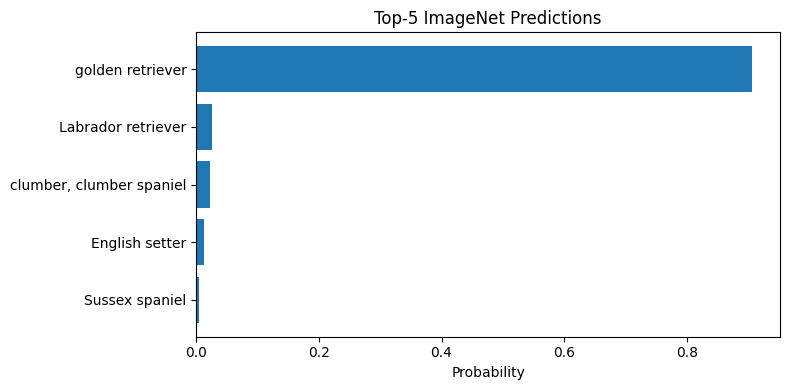

In [ ]:
from PIL import Image
import requests
from io import BytesIO
import torch
import pandas as pd
import matplotlib.pyplot as plt

from transformers import AutoImageProcessor, AutoModelForImageClassification

model_id = "facebook/dinov2-small-imagenet1k-1-layer"

processor = AutoImageProcessor.from_pretrained(model_id)
classifier = AutoModelForImageClassification.from_pretrained(model_id)
classifier.eval()

device = "cuda" if torch.cuda.is_available() else "cpu"
classifier.to(device)
print("Using device:", device)

path = "data/Golden_Retriever_Carlos_(10581910556).jpg"
image = Image.open(path).convert("RGB")
image_source = path

plt.figure(figsize=(5, 5))
plt.imshow(image)
plt.axis("off")
plt.title("Input image")
plt.show()

inputs = processor(images=image, return_tensors="pt").to(device)

with torch.no_grad():
    outputs = classifier(**inputs)
    probs = torch.softmax(outputs.logits, dim=-1)[0]


top5 = torch.topk(probs, k=5)
rows = []
for score, class_id in zip(top5.values, top5.indices):
    class_id = int(class_id.item())
    rows.append({
        "rank": len(rows) + 1,
        "imagenet_class_id": class_id,
        "label": classifier.config.id2label[class_id],
        "probability": float(score.item()),
    })

predictions_df = pd.DataFrame(rows)
display(predictions_df)

best = predictions_df.iloc[0]
print("Image source:", image_source)
print(f"Top prediction: {best['label']} with probability {best['probability']:.2%}")

plt.figure(figsize=(8, 4))
plt.barh(predictions_df["label"][::-1], predictions_df["probability"][::-1])
plt.xlabel("Probability")
plt.title("Top-5 ImageNet Predictions")
plt.tight_layout()
plt.show()
